In [1]:
import modules.data as d
import modules.model2 as m
import modules.train as t
import modules.utils as u

import torch
import torch.nn as nn
from pathlib import Path


In [2]:
# dataset dir
datasets = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')

# get device
device, generator = u.Devices().auto_set_device()

# get data
data = d.Data(
    # datasets
    tcga_project = 'TCGA-BRCA',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',

    # dirs
    tcga_dir = datasets / 'tcga',
    relation_filepath = datasets / 'other/relation_ohe.csv',
    
    # col, filter
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Metastatic']},
    max_subset=120,
)

*** Device() ***
device = cuda:3

**** Data() ****
log0_method      log1p            str
class_weights    (6,)             Tensor (cuda:3)
gene_counts      (4383, 567)      DataFrame
metadata         (567, 3)         DataFrame
relation         (75939, 19)      DataFrame
node_id_map      4383             dict
masks            305              list
X                (567, 4383, 1)   Tensor (cuda:3)
y                (567, 6)         Tensor (cuda:3)
y_labels         6                list
num_samples      567              int
num_nodes        4383             int
num_features     1                int
num_labels       6                int
num_masks        305              int



---

In [3]:
data_module = t.DataModule(
    X=data.X,
    y=data.y,
    generator=generator,
    # batch_size=16,
    # val_size=0.15,
    # test_size=0.15
)

training_module = t.MultiTrainingModule(
    model_class=m.MLPClassifier,
    model_kwargs={
        'in_features':data.num_nodes,
        'out_features':data.num_labels,
        'flatten':True,
    },

    training_class=t.ClassifierTrainingModule,
    training_kwargs={
        'data_module':data_module,
        'loss_fn':nn.CrossEntropyLoss(data.class_weights),
        'optimizer':torch.optim.Adam,
        'num_epochs':20,
        'verbose':False
    },

    num_trials=3,
    comment='tmod_test'
)

100%|██████████| 3/3 [00:03<00:00,  1.10s/it]


In [4]:
# training_module.run()

In [5]:
training_module.summary

,tot_loss,accuracy,precision,recall,f1
mean,5.594999,0.854902,0.889071,0.854902,0.854079
std,0.835419,0.006792,0.005138,0.006792,0.005361


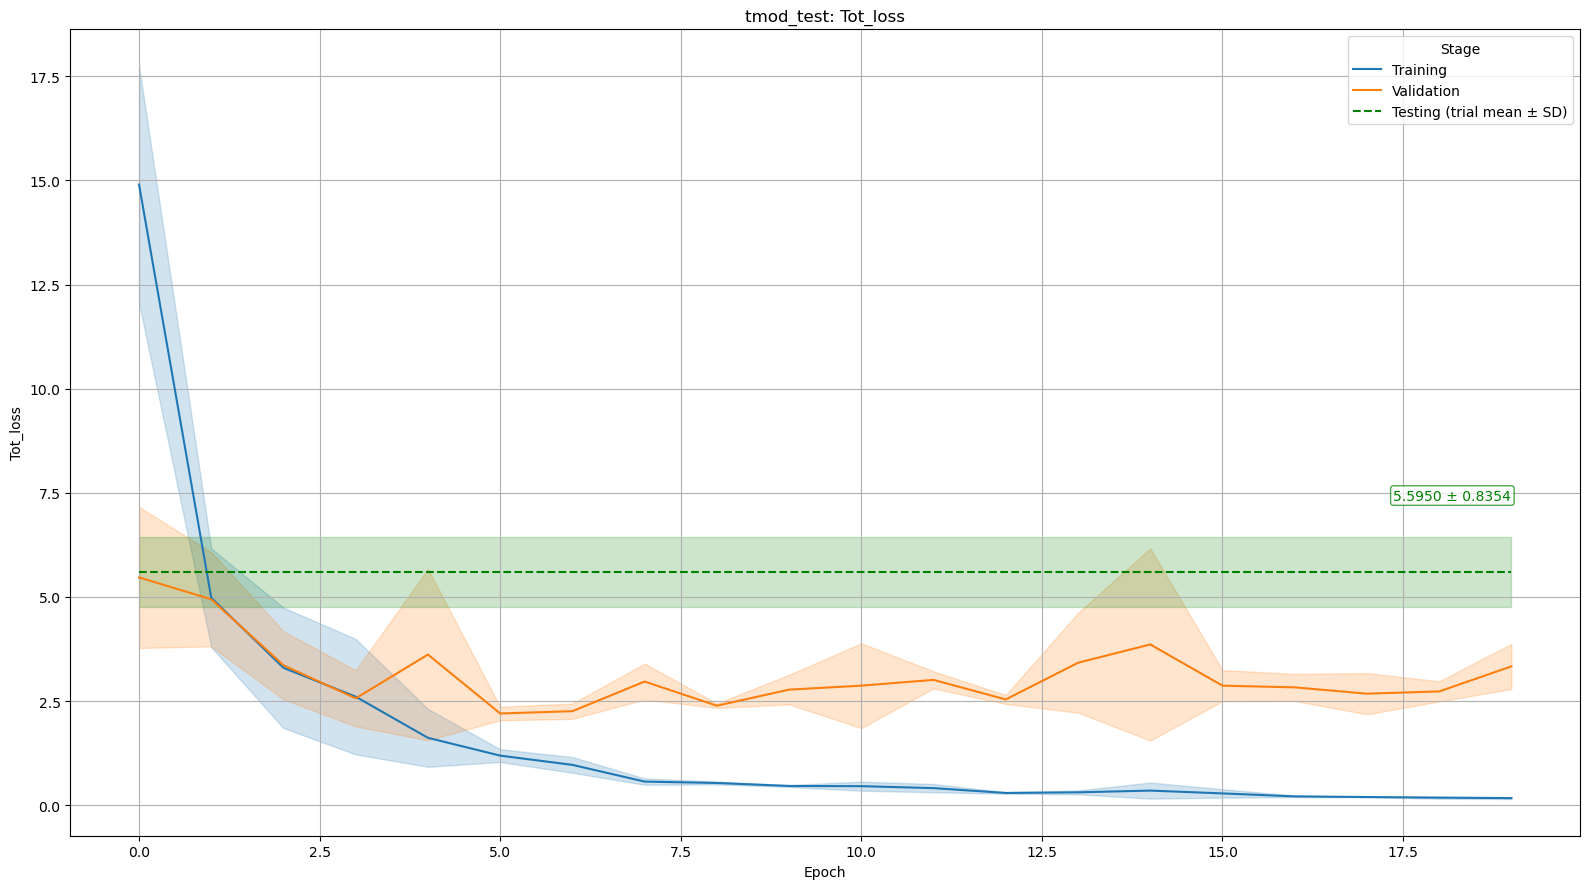

In [6]:
training_module.figs['tot_loss']